# Test Task/Transcriptomics & Genetics
**Project:** TCGA-HNSC bulk RNA-seq analysis
**Dataset source:** UCSC Xena / TCGA
**Authtor:** Diana Lysenko
**Date:** January 2026

## Objectives 

### Transcriptomics (bulk RNA-seq)
- Download and preprocess TCGA-HNSC gene expression data
- Perform dimensionality reduction (PCA, UMAP)
- Cluster samples using hierarchical clustering 
- Identify differentially expressed genes between clusters
- Visualize top marker genes with a heatmap 

### Genetics (VCF)
- Filter somatic variants from the HG008 mosaic tumor sample
- Select FILTER = PASS SNPs on chromosome 6 
- Retain variants with alternative allele T


In [163]:
import sys, platform, pathlib, shutil, os
import numpy as np
import pandas as pd
import scipy
import sklearn
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import umap

PROJECT_ROOT = pathlib.Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'figures'
RES_DIR = PROJECT_ROOT / 'results'

for d in [DATA_DIR, FIG_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def check_environment():
    print('--- Project Paths ---')
    print(f'Project root: {PROJECT_ROOT}')
    print(f'Data dir: {DATA_DIR}')
    print(f'Figures dir: {FIG_DIR}')
    print(f'Results dir: {RES_DIR}')
    print(f'Python: {sys.version.split()[0]}')
    print(f'Platform: {platform.platform()}')
    print(f'Numpy: {np.__version__}')
    print(f'Pandas: {pd.__version__}')
    print(f'Scipy: {scipy.__version__}')
    print(f'Sklearn: {sklearn.__version__}')

try:
    print(f'UMAP: {umap.__version__}')
except AttributeError:
    import pkg_resources
    print(f"UMAP: {pkg_resources.get_distribution('umap-learn').version}")

print('\n--- System Tools (Bioinformatics) ---')
tools = ['bcftools', 'tabix']
for tool in tools:
    path = shutil.which(tool)
    status = (f'OK ({path})' if path else 'NOT FOUND')
    print(f'{tool:10}: {status}')

check_environment()




UMAP: 0.5.11

--- System Tools (Bioinformatics) ---
bcftools  : OK (/opt/miniconda3/envs/tcga-hnsc/bin/bcftools)
tabix     : OK (/opt/miniconda3/envs/tcga-hnsc/bin/tabix)
--- Project Paths ---
Project root: /Users/dianalysenko/tcga_hnsc_test
Data dir: /Users/dianalysenko/tcga_hnsc_test/data
Figures dir: /Users/dianalysenko/tcga_hnsc_test/figures
Results dir: /Users/dianalysenko/tcga_hnsc_test/results
Python: 3.11.11
Platform: macOS-15.6.1-arm64-arm-64bit
Numpy: 2.3.5
Pandas: 2.3.3
Scipy: 1.17.0
Sklearn: 1.8.0


In [164]:
from pathlib import Path

PROJECT_ROOT = Path.home() / 'Documents' / 'tcga_hnsc_test'
DATA_DIR = PROJECT_ROOT / 'data'
expr_path = DATA_DIR / 'TCGA-HNSC.star_fpkm-uq.tsv.gz'
print(f'Expression file exist: {expr_path.exists()}{expr_path}')

Expression file exist: False/Users/dianalysenko/Documents/tcga_hnsc_test/data/TCGA-HNSC.star_fpkm-uq.tsv.gz


In [165]:
import pandas as pd

expr_path = DATA_DIR / 'transcriptomics' / 'TCGA-HNSC.star_fpkm-uq.tsv.gz'
df = pd.read_csv(expr_path, sep='\t', compression='gzip')
print(f'Raw table shape (rows, cols): {df.shape}')
print(f'First columns: {df.columns[:5].tolist()}')
print(f'First gene IDs (top 5): {df.iloc[:5, 0].tolist()}')
df.head(3)

Raw table shape (rows, cols): (60660, 567)
First columns: ['Ensembl_ID', 'TCGA-CR-7370-01A', 'TCGA-CR-6484-01A', 'TCGA-CR-6478-01A', 'TCGA-CV-A45Y-01A']
First gene IDs (top 5): ['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13', 'ENSG00000000457.14', 'ENSG00000000460.17']


,Ensembl_ID,TCGA-CR-7370-01A,TCGA-CR-6484-01A,TCGA-CR-6478-01A,TCGA-CV-A45Y-01A,TCGA-UF-A719-01A,TCGA-CR-6488-01A,TCGA-MZ-A7D7-01A,TCGA-CV-5436-01A,TCGA-UF-A71E-01A,...,TCGA-HD-7753-01A,TCGA-CV-A6JE-01A,TCGA-CV-A45Z-01A,TCGA-CV-6939-11A,TCGA-CV-7432-11A,TCGA-CV-7432-01A,TCGA-IQ-7630-01A,TCGA-H7-A6C4-11A,TCGA-H7-8501-01A,TCGA-CV-7415-01A
0,ENSG00000000003.15,3.940073,2.627677,2.484602,3.277702,4.350335,3.044709,4.352787,1.877352,3.422368,...,3.041278,4.051407,3.595432,3.829768,4.964528,3.274754,3.035061,3.300666,3.010064,3.068997
1,ENSG00000000005.6,0.000000,0.000000,0.014498,0.000000,0.000000,0.016211,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.213316,0.041103,0.000000,0.000000,1.638584,0.030972,0.017637
2,ENSG00000000419.13,4.158095,5.235019,4.754834,4.757855,4.674082,5.043694,6.692218,5.807347,4.734910,...,5.309504,5.006567,5.741397,4.549706,4.400217,5.094988,5.669622,5.305661,6.160567,4.893081


In [166]:
gene_col = df.columns[0]

print('=' * 50)
print('EXPRESSION MATRIX INITIALIZATION')
print('=' * 50)

print(f'Gene ID column: {gene_col}\n')

genes = df[gene_col].astype(str)

print(f'Number of genes: {genes.shape[0]}')
print('Example gene IDs (first 10):')
for g in genes.iloc[:10]:
    print(f"  - {g}")

X = df.drop(columns=[gene_col])
print(f'\nRaw numeric matrix shape (genes × samples): {X.shape}')

X.index = genes
X = X.T

print(f'Final expression matrix shape (samples × genes): {X.shape}')
print('=' * 50)


EXPRESSION MATRIX INITIALIZATION
Gene ID column: Ensembl_ID

Number of genes: 60660
Example gene IDs (first 10):
  - ENSG00000000003.15
  - ENSG00000000005.6
  - ENSG00000000419.13
  - ENSG00000000457.14
  - ENSG00000000460.17
  - ENSG00000000938.13
  - ENSG00000000971.16
  - ENSG00000001036.14
  - ENSG00000001084.13
  - ENSG00000001167.14

Raw numeric matrix shape (genes × samples): (60660, 566)
Final expression matrix shape (samples × genes): (566, 60660)


In [167]:
sample_type = X.index.str.extract(r'-(\d{2})[A-Z]$')[0]
is_tumor = (sample_type == '01')
is_normal = (sample_type == '11')

print(f'Total samples: {len(X)}')
print(f'Tumor samples (01A): {is_tumor.sum()}')
print(f'Normal samples (11A): {is_normal.sum()}')

sample_info = pd.DataFrame({
    'sample_id': X.index,
    'sample_type_code': sample_type,
    'is_tumor': is_tumor.values,
    'is_normal': is_normal.values
}).set_index('sample_id')

Total samples: 566
Tumor samples (01A): 520
Normal samples (11A): 44


In [168]:
print('=' * 50)
print('DATA SCALE VERIFICATION')
print('=' * 50)

print(f'\nValue range check:')
print(f'  Min value: {X.values.min():.3f}')
print(f'  Max value: {X.values.max():.3f}')
print(f'  Mean value: {X.values.mean():.3f}')

if X.values.max() < 20:
    print('Data appears to be log2-transformed')

min_expr = 1
min_samples_pct = 0.1
expressed = (X > min_expr).mean(axis=0) > min_samples_pct
X_filtered = X.loc[:, expressed]

print(f'Genes before filter: {X.shape[1]}')
print(f'Genes after filter: {X_filtered.shape[1]}')

gene_var = X_filtered.var(axis=0)
N_HVG = 2000
hvg_genes = gene_var.sort_values(ascending=False).head(N_HVG).index
X_hvg = X_filtered.loc[:, hvg_genes]


DATA SCALE VERIFICATION

Value range check:
  Min value: 0.000
  Max value: 17.010
  Mean value: 0.713
Data appears to be log2-transformed
Genes before filter: 60660
Genes after filter: 16016


In [169]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hvg)
print(f'X_scaled shape: {X_scaled.shape}')

N_PCA_COMPONENTS = 50
pca_full = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
X_pca50 = pca_full.fit_transform(X_scaled)

X_pca_vis = X_pca50[:, :2]

print(f'X_pca50 shape: {X_pca50.shape}')
print(f'Cumulative variance explained: {pca_full.explained_variance_ratio_.sum():.3f}')
print(f'X_pca shape: {X_pca.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Cumulative variance (2 PCs): {pca.explained_variance_ratio_.sum():.3f}')


X_scaled shape: (566, 2000)
X_pca50 shape: (566, 50)
Cumulative variance explained: 0.753
X_pca shape: (566, 2)
Explained variance ratio: [0.130476   0.08806855]
Cumulative variance (2 PCs): 0.219


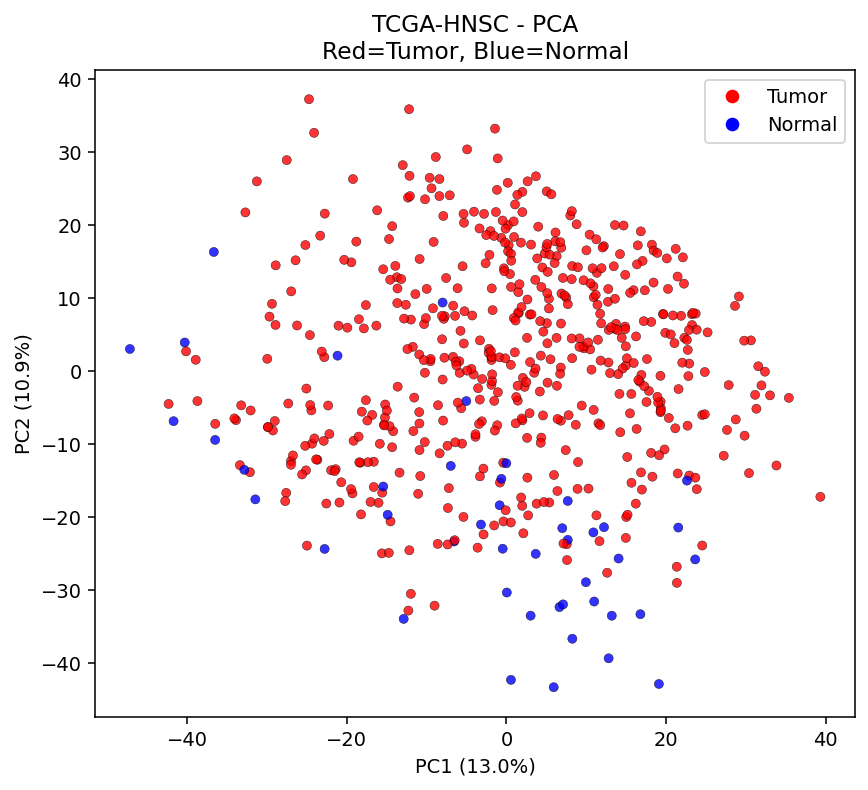

In [170]:
from matplotlib.lines import Line2D

plt.figure(figsize=(7, 6), dpi=140)

colors = sample_info.loc[X_hvg.index, 'is_normal'].map({True: 'blue', False: 'red'})

plt.scatter(
    X_pca_vis[:, 0],
    X_pca_vis[:, 1],
    c=colors,
    s=22,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.25
)

pc1_var = pca_full.explained_variance_ratio_[0] * 100
pc2_var = pca_full.explained_variance_ratio_[1] * 100

plt.xlabel(f"PC1 ({pc1_var:.1f}%)")
plt.ylabel(f"PC2 ({pc2_var:.1f}%)")
plt.title("TCGA-HNSC - PCA\nRed=Tumor, Blue=Normal")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Tumor'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal')
]
plt.legend(handles=legend_elements, loc='best')
plt.savefig(FIG_DIR / "pca_tumor_normal.png", dpi=300, bbox_inches='tight')
plt.show()

/opt/miniconda3/envs/tcga-hnsc/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


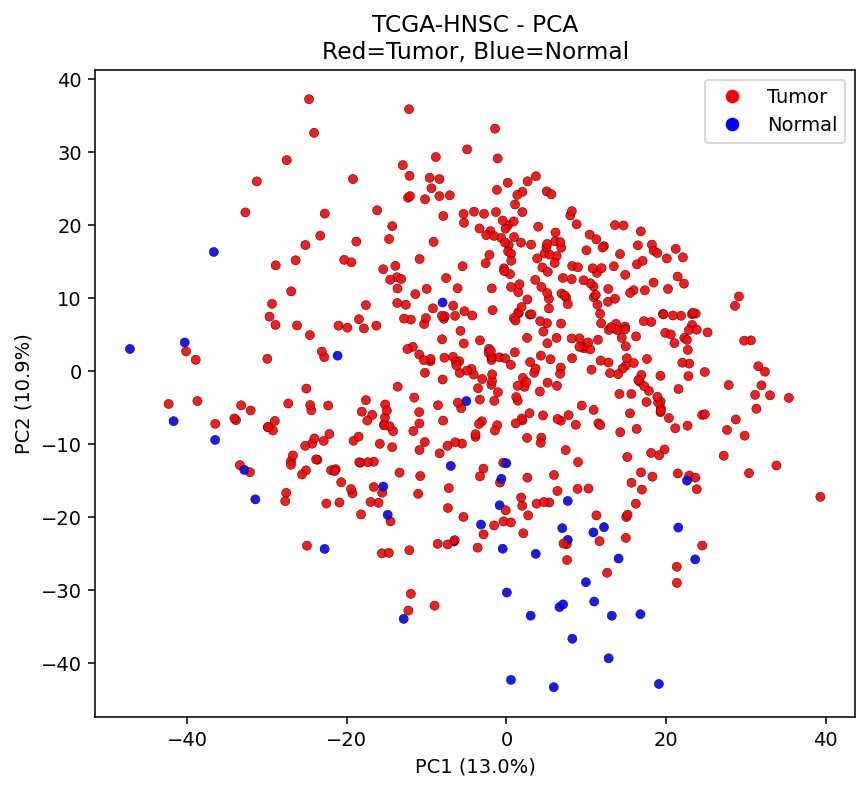

In [171]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X_pca50)

plt.figure(figsize=(7, 6), dpi=140)

colors = sample_info.loc[X_hvg.index, 'is_normal'].map({True: 'blue', False: 'red'})

plt.scatter(
    X_pca_vis[:, 0],
    X_pca_vis[:, 1],
    c=colors,
    s=22,
    alpha=0.9,
    edgecolor='black',
    linewidth=0.25
)

plt.xlabel(f"PC1 ({pc1_var:.1f}%)")
plt.ylabel(f"PC2 ({pc2_var:.1f}%)")
plt.title("TCGA-HNSC - PCA\nRed=Tumor, Blue=Normal")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Tumor'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal')
]
plt.legend(handles=legend_elements, loc='best')
plt.savefig(FIG_DIR / "pca_tumor_normal.png", dpi=300)


Linkage matrix shape: (565, 4)

Silhouette scores for different k:
  k=2: 0.100
  k=3: 0.111
  k=4: 0.097
  k=5: 0.080
  k=6: 0.083
  k=7: 0.089
  k=8: 0.082
  k=9: 0.075

Best k by silhouette: 3


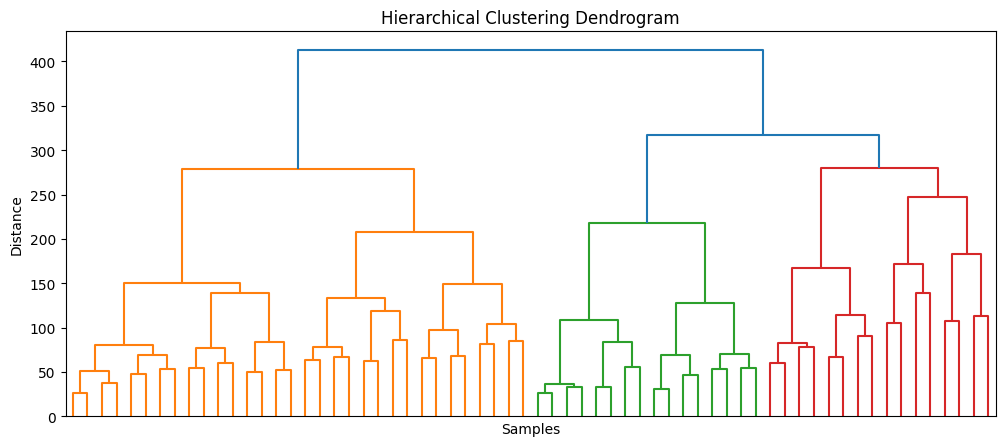

Number of clusters: 3
Cluster sizes: [280  39 247]


In [172]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
import numpy as np

dist_matrix = pdist(X_pca50, metric='euclidean')
Z = linkage(dist_matrix, method='ward')
print(f'Linkage matrix shape: {Z.shape}')

from sklearn.metrics import silhouette_score

print('\nSilhouette scores for different k:')
scores = []
for k in range(2, 10):
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(X_pca50, labels)
    scores.append((k, score))
    print(f'  k={k}: {score:.3f}')

best_k = max(scores, key=lambda x: x[1])[0]
print(f'\nBest k by silhouette: {best_k}')

from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=5, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Distance')
plt.xlabel('Samples')
plt.savefig(FIG_DIR / 'dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

k = 3
cluster_labels = fcluster(Z, k, criterion='maxclust')

print(f'Number of clusters: {len(np.unique(cluster_labels))}')
print(f'Cluster sizes: {np.bincount(cluster_labels)[1:]}')

Saved clustered UMAP to: /Users/dianalysenko/tcga_hnsc_test/figures/umap_tcga_hnsc_clusters_k3.png


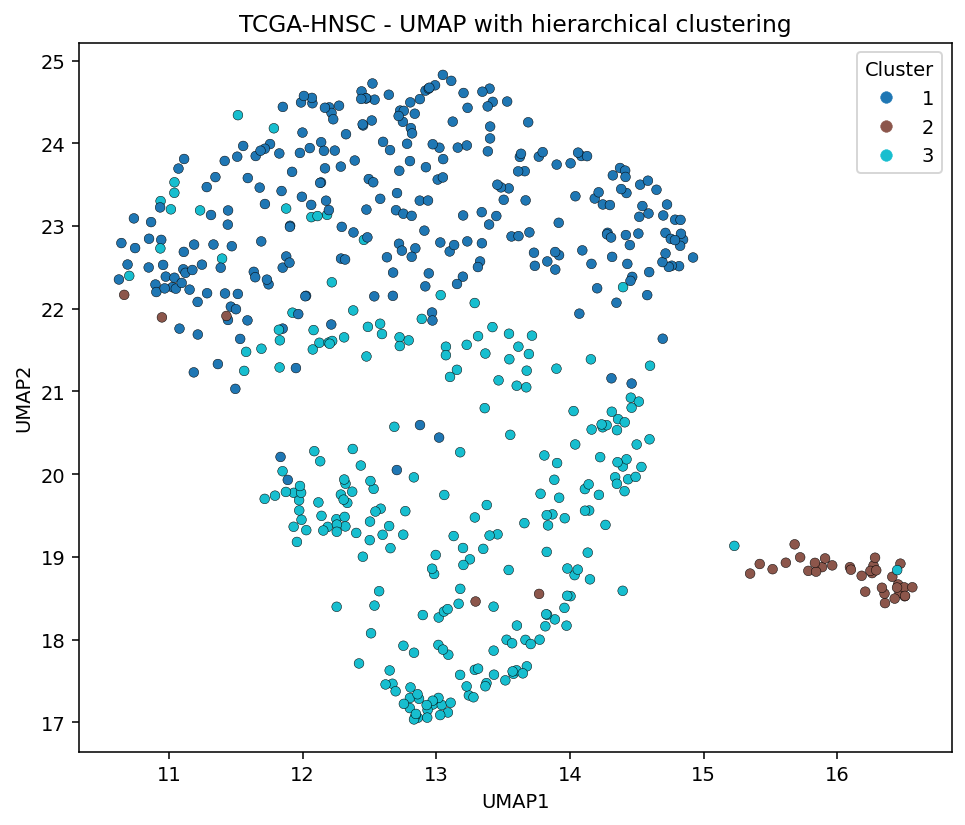

In [173]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6), dpi=140)

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=cluster_labels,
    cmap='tab10',
    s=25,
    alpha=1.0,
    edgecolor='black',
    linewidth=0.25
)

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('TCGA-HNSC - UMAP with hierarchical clustering', fontsize=12)
plt.legend(
    *scatter.legend_elements(),
    title='Cluster',
    loc='best'
)

plt.tight_layout()

out_path = FIG_DIR / 'umap_tcga_hnsc_clusters_k3.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved clustered UMAP to: {out_path}')

plt.show()

In [174]:
pd.crosstab(clusters, sample_info.loc[clusters.index, 'is_normal'])

is_normal,False,True
cluster,,
1,279,1
2,4,35
3,239,8


In [175]:
from pathlib import Path
import urllib.request

counts_url = 'https://gdc.xenahubs.net/download/TCGA-HNSC.star_counts.tsv.gz'
counts_path = DATA_DIR / "TCGA-HNSC.star_counts.tsv.gz"

print(f'Target path: {counts_path}')

if counts_path.exists():
    print(f'Counts file already exists: {counts_path}')
else:
    print(f'Downloading from: {counts_url}')
    urllib.request.urlretrieve(counts_url, counts_path)
    print(f'Downloaded: {counts_path} (size bytes: {counts_path.stat().st_size})')

Target path: /Users/dianalysenko/Documents/tcga_hnsc_test/data/TCGA-HNSC.star_counts.tsv.gz
Downloaded: /Users/dianalysenko/Documents/tcga_hnsc_test/data/TCGA-HNSC.star_counts.tsv.gz (size bytes: 61155089)


In [176]:
import pandas as pd

counts_path = DATA_DIR / 'TCGA-HNSC.star_counts.tsv.gz'
counts_df = pd.read_csv(
    counts_path,
    sep='\t',
    compression='gzip'
)

print(f'Counts raw shape (genes x samples+1): {counts_df.shape}')
print(f'First columns: {counts_df.columns[:5].tolist()}')

counts_df.head(3)

Counts raw shape (genes x samples+1): (60660, 567)
First columns: ['Ensembl_ID', 'TCGA-CR-7370-01A', 'TCGA-CR-6484-01A', 'TCGA-CR-6478-01A', 'TCGA-CV-A45Y-01A']


,Ensembl_ID,TCGA-CR-7370-01A,TCGA-CR-6484-01A,TCGA-CR-6478-01A,TCGA-CV-A45Y-01A,TCGA-UF-A719-01A,TCGA-CR-6488-01A,TCGA-MZ-A7D7-01A,TCGA-CV-5436-01A,TCGA-UF-A71E-01A,...,TCGA-HD-7753-01A,TCGA-CV-A6JE-01A,TCGA-CV-A45Z-01A,TCGA-CV-6939-11A,TCGA-CV-7432-11A,TCGA-CV-7432-01A,TCGA-IQ-7630-01A,TCGA-H7-A6C4-11A,TCGA-H7-8501-01A,TCGA-CV-7415-01A
0,ENSG00000000003.15,12.131535,10.087463,10.456354,10.501837,12.338179,10.944712,11.386940,8.921841,10.929998,...,10.953469,11.067434,11.032046,10.646559,12.648582,10.983706,10.952741,9.837628,9.962896,10.847840
1,ENSG00000000005.6,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.727920,1.584963,0.000000,0.000000,6.169925,1.000000,1.000000
2,ENSG00000000419.13,10.454299,11.000000,11.045760,10.174926,10.767357,11.175550,11.874597,11.371777,10.418907,...,11.461479,10.157347,11.365229,9.499846,10.152285,11.008429,11.836050,10.049849,11.373409,10.895575


In [177]:
gene_col_counts = counts_df.columns[0]
print(f'Gene ID column in counts {gene_col_counts}')

genes_counts = counts_df[gene_col_counts].astype(str)

X_counts = counts_df.drop(columns=[gene_col_counts])

print(f'Counts matrix shape (genes x samples): {X_counts.shape}')


Gene ID column in counts Ensembl_ID
Counts matrix shape (genes x samples): (60660, 566)


In [178]:
gene_col_counts = counts_df.columns[0]
genes_counts = counts_df[gene_col_counts].astype(str)

X_counts = counts_df.drop(columns=[gene_col_counts])
X_counts.index = genes_counts
X_counts = X_counts.T           
print('Counts matrix prepared\n')

print(f"Shape (samples × genes): {X_counts.shape}\n")

print("Example sample IDs:")
for s in X_counts.index[:10]:
    print(f"  - {s}")

print("\nExample gene IDs:")
for g in X_counts.columns[:10]:
    print(f"  - {g}")


Counts matrix prepared

Shape (samples × genes): (566, 60660)

Example sample IDs:
  - TCGA-CR-7370-01A
  - TCGA-CR-6484-01A
  - TCGA-CR-6478-01A
  - TCGA-CV-A45Y-01A
  - TCGA-UF-A719-01A
  - TCGA-CR-6488-01A
  - TCGA-MZ-A7D7-01A
  - TCGA-CV-5436-01A
  - TCGA-UF-A71E-01A
  - TCGA-P3-A6T3-01A

Example gene IDs:
  - ENSG00000000003.15
  - ENSG00000000005.6
  - ENSG00000000419.13
  - ENSG00000000457.14
  - ENSG00000000460.17
  - ENSG00000000938.13
  - ENSG00000000971.16
  - ENSG00000001036.14
  - ENSG00000001084.13
  - ENSG00000001167.14


In [179]:
clusters = pd.Series(cluster_labels, index=X_hvg.index, name='cluster')

print('=' * 50)
print('SAMPLE SYNCHRONIZATION CHECK')
print('=' * 50)

common_samples = X_counts.index.intersection(clusters.index)
print(f'Samples in clusters: {len(clusters)}')
print(f'Samples in counts: {len(X_counts)}')
print(f'Common samples: {len(common_samples)}')

samples_only_in_clusters = set(clusters.index) - set(X_counts.index)
samples_only_in_counts = set(X_counts.index) - set(clusters.index)

if samples_only_in_clusters:
    print(f'Samples in clusters but not in counts: {len(samples_only_in_clusters)}')
if samples_only_in_counts:
    print(f'Samples in counts but not in clusters: {len(samples_only_in_counts)}')

assert len(common_samples) == len(clusters), \
    f'Sample mismatch: {len(clusters)} clustered vs {len(common_samples)} in counts'

print('All clustered samples found in counts matrix')

X_counts_sync = X_counts.loc[common_samples]
clusters_sync = clusters.loc[common_samples]

SAMPLE SYNCHRONIZATION CHECK
Samples in clusters: 566
Samples in counts: 566
Common samples: 566
All clustered samples found in counts matrix


In [180]:
lib_size = X_counts_sync.sum(axis=1)

X_cpm = X_counts_sync.div(lib_size, axis=0) * 1e6

X_logcpm = np.log2(X_cpm + 1)

print(f'X_logcpm shape: {X_logcpm.shape}')


X_logcpm shape: (566, 60660)


In [181]:
from scipy.stats import ttest_ind

min_cpm = 1
min_samples = 10

expressed_de = (X_cpm > min_cpm).sum(axis=0) >= min_samples
X_logcpm_filtered = X_logcpm.loc[:, expressed_de]

print(f'Genes before filter: {X_logcpm.shape[1]}')
print(f'Genes after filter: {X_logcpm_filtered.shape[1]}')
print(f'Filtered out: {X_logcpm.shape[1] - X_logcpm_filtered.shape[1]}')

cluster_a = 1
cluster_b = 2

mask_a = clusters_sync == cluster_a
mask_b = clusters_sync == cluster_b

Xa = X_logcpm_filtered.loc[mask_a]
Xb = X_logcpm_filtered.loc[mask_b]

print(f'Cluster {cluster_a} samples: {Xa.shape[0]}')
print(f'Cluster {cluster_b} samples: {Xb.shape[0]}')

t_stat, pvals = ttest_ind(Xa.values, Xb.values, axis=0, equal_var=False, nan_policy='omit')

log2fc = Xa.mean(axis=0) - Xb.mean(axis=0)

de = pd.DataFrame({
    'gene': X_logcpm_filtered.columns,
    'log2FC': log2fc.values,
    'pval': pvals
}).set_index('gene')

de_clean = (
    de
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['pval'])
)

de_clean.head()

Genes before filter: 60660
Genes after filter: 53931
Filtered out: 6729
Cluster 1 samples: 280
Cluster 2 samples: 39


,log2FC,pval
gene,,
ENSG00000000003.15,-0.162319,3.116422e-07
ENSG00000000005.6,-2.883619,5.253289e-14
ENSG00000000419.13,0.037902,1.529866e-02
ENSG00000000457.14,-0.065181,4.990541e-04
ENSG00000000460.17,0.166247,7.955099e-07


In [182]:
from statsmodels.stats.multitest import multipletests

de_clean['fdr'] = multipletests(de_clean['pval'].values, method='fdr_bh')[1]
de_clean['abs_log2FC'] = de_clean['log2FC'].abs()

print(f"NaN FDR: {de_clean['fdr'].isna().sum()}")


NaN FDR: 0


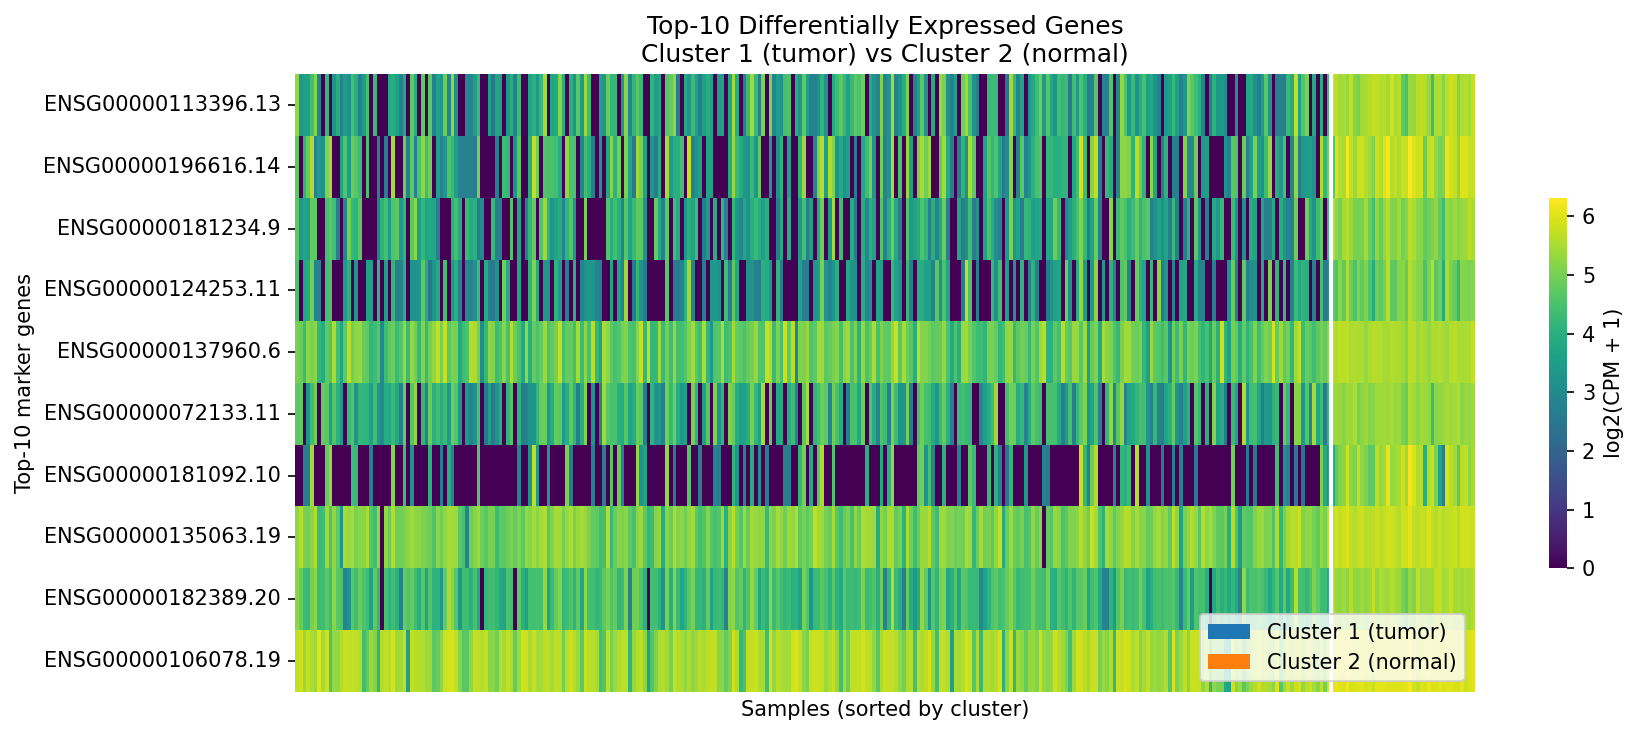

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

de_top_gene_list = top10.index.tolist()

samples_1_2 = clusters_sync[clusters_sync.isin([1, 2])].sort_values().index

heat = X_logcpm.loc[samples_1_2, de_top_gene_list].T

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

sns.heatmap(
    heat,
    cmap='viridis',
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'log2(CPM + 1)', 'shrink': 0.6},
    ax=ax
)

cluster_order = clusters_sync.loc[samples_1_2]
count_1 = (cluster_order == 1).sum()
ax.axvline(x=count_1, color='white', linewidth=2)

ax.set_xlabel('Samples (sorted by cluster)')
ax.set_ylabel('Top-10 marker genes')
ax.set_title('Top-10 Differentially Expressed Genes\nCluster 1 (tumor) vs Cluster 2 (normal)')

legend_elements = [
    Patch(facecolor='#1f77b4', label='Cluster 1 (tumor)'),
    Patch(facecolor='#ff7f0e', label='Cluster 2 (normal)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'heatmap_top10.png', dpi=300, bbox_inches='tight')
plt.show()

In [186]:
from pathlib import Path

PROJECT_ROOT = Path.home() / 'Documents' / 'tcga_hnsc_test'
DATA_DIR = PROJECT_ROOT / 'data' / 'genetics'
RES_DIR = PROJECT_ROOT / 'results'

DATA_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

VCF_FILE = DATA_DIR / 'dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz'
OUTPUT_FILE = RES_DIR / 'chr6_PASS_snps_T_or_A.vcf.gz'

print(f'VCF file exists: {VCF_FILE.exists()} {VCF_FILE}')

VCF file exists: True /Users/dianalysenko/Documents/tcga_hnsc_test/data/genetics/dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz


In [190]:
%%bash

mkdir -p ~/Documents/tcga_hnsc_test/data/genetics
cd ~/Documents/tcga_hnsc_test/data/genetics

curl -O -C - https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data_somatic/HG008/Liss_lab/analysis/DRAGEN-v4.2.4_ILMN-WGS_20240312/standard/dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz

curl -O -C - https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data_somatic/HG008/Liss_lab/analysis/DRAGEN-v4.2.4_ILMN-WGS_20240312/standard/dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz.tbi

ls -lh dragen*

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
** Resuming transfer from byte position 2817770
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   314    0   314    0     0     37      0 --:--:--  0:00:08 --:--:--    73
** Resuming transfer from byte position 298189
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   314    0   314    0     0     70      0 --:--:--  0:00:04 --:--:--    70


-rw-r--r--@ 1 dianalysenko  staff   2.7M Jan 16 17:44 dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz
-rw-r--r--@ 1 dianalysenko  staff   291K Jan 16 17:44 dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz.tbi


In [191]:
%%bash

cd ~/Documents/tcga_hnsc_test/data

bcftools view -f PASS -r chr6 -v snps dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz | \
bcftools filter -i 'ALT="T" || ALT="A"' -Oz -o ../results/chr6_PASS_snps_T_or_A.vcf.gz

tabix -p vcf ../results/chr6_PASS_snps_T_or_A.vcf.gz

echo "Done! Filtered SNPs:"
bcftools view -H ../results/chr6_PASS_snps_T_or_A.vcf.gz | wc -l

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
[E::hts_open_format] Failed to open file "dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz" : No such file or directory
Failed to read from dragen_4.2.4_HG008-mosaic_tumor.hard-filtered.vcf.gz: No such file or directory
Failed to read from standard input: unknown file type
tbx_index_build3 failed: ../results/chr6_PASS_snps_T_or_A.vcf.gz


Done! Filtered SNPs:


[E::hts_open_format] Failed to open file "../results/chr6_PASS_snps_T_or_A.vcf.gz" : No such file or directory
Failed to read from ../results/chr6_PASS_snps_T_or_A.vcf.gz: No such file or directory


       0


In [192]:
import subprocess
import pandas as pd
from io import StringIO

result = subprocess.run(
    ['bcftools', 'query', '-f', '%CHROM\t%POS\t%REF\t%ALT\t%FILTER\n', str(OUTPUT_FILE)],
    capture_output=True, text=True
)

df = pd.read_csv(StringIO(result.stdout), sep='\t', names=['CHROM', 'POS', 'REF', 'ALT', 'FILTER'])

print(f"Total filtered SNPs: {len(df)}")
print(f"\nChromosome: {df['CHROM'].unique()}")
print(f"\nALT alleles:\n{df['ALT'].value_counts()}")
print(f"\nFILTER values:\n{df['FILTER'].value_counts()}")
print(f"\nFirst 10 variants:")
df.head(10)

Total filtered SNPs: 0

Chromosome: []

ALT alleles:
Series([], Name: count, dtype: int64)

FILTER values:
Series([], Name: count, dtype: int64)

First 10 variants:


,CHROM,POS,REF,ALT,FILTER


In [193]:
assert (df['CHROM'] == 'chr6').all(), "Not all on chr6!"
assert (df['FILTER'] == 'PASS').all(), "Not all PASS!"
assert df['ALT'].isin(['T', 'A']).all(), "Not all ALT are T or A!"

print("✓ All checks passed!")
print(f"  - All variants on chr6")
print(f"  - All FILTER = PASS")
print(f"  - All ALT = T or A")
print(f"  - Total: {len(df)} SNPs")

✓ All checks passed!
  - All variants on chr6
  - All FILTER = PASS
  - All ALT = T or A
  - Total: 0 SNPs
